In [34]:
import pandas as pd 
import numpy as np 
from glob import glob
import os
import geopandas as gpd

import csv
import json

from ast import literal_eval

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pd.set_option('display.max_columns', None)


# Read data

In [50]:
buffertracker = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/data/nonevents_ofinterest/buffertimes_for_nceievents.csv")

display(buffertracker.head(2))

print(len(buffertracker))

# Combine stats for events AND their buffers. 

stats_events = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_events_rsc.csv") #HERE!! stats_wQPE_rerun.csv or stats.csv

stats_buffer = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_buffer_rsc.csv") # HERE!! note that this has a lot more data in it than the buffer tracker (what we actually needed to run). Why? bc when we do operations model preds, we run it statewide -- so ALL locations / wfos (for all cams) are included in the stats here. We will want to inner join with the tracker, buffertracker to grab just those that we needed.  
# stats_bufferwQPE_rerun
# stats_buffer

print()

stats_buffer = stats_buffer.drop(columns = ['id_event','id_ep']) # these were just set to the datetimes, meaningless at the moment
stats_buffer = stats_buffer.rename(columns = {"id_type":"type"})

# To connect the buffer data to the events data, use the buffer tracker dataframe we saved out which has the event (id_event), buffer times, location. The code for setting up that df was in /home/csutter/DRIVE-clean/weather_events/notebooks/ncei_dataset_analysis.ipynb (but the data is saved out and we can use it), but it can be merged to stats_buffer via location, which will tie the event id to buffer -- which is what we need here for plotting buffer times with the events themselcves

buffertracker = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/data/nonevents_ofinterest/buffertimes_for_nceievents.csv")

stats_buffer_connect = stats_buffer.merge(buffertracker, how = "inner", left_on = ["id_loc", "id_wfo", "datetime"], right_on = ["buffer_loc", "buffer_wfo", "buffer_datetime"])

# adjust cols

# rename cols to match stats_events so that concat of dfs is clean
# stats_buffer_use = stats_buffer_connect.rename(columns = {"buffer_for_event_id":"id_event","buffer_wfo":"id_wfo","buffer_loc":"id_loc"})

stats_buffer_connect['id_type'] = stats_buffer_connect['type'] + '_' + stats_buffer_connect['buffer_type']
stats_buffer_connect['id_ep'] = 999
stats_buffer_connect['id_event'] = stats_buffer_connect['buffer_for_event_id'] #THIS is where id_event is connected to match that of the NCEI events. See larger "To connect" note above. 
stats_buffer_connect = stats_buffer_connect.drop(columns = ['type', 'buffer_wfo', 'buffer_loc', 'Unnamed: 0', 'buffer_type', 'buffer_datetime','buffer_for_event_id'])

print(len(stats_events)) # stats for ncei events, split by date and location
print(len(stats_buffer)) # buffers for datetimes needed for ncei events PLUS ran statewide -- so much longer than the actual amount of datetimes needed
print(len(buffertracker)) # buffer times needed (tracker)
print(len(stats_buffer_connect)) # after merging, should be similar to above, although some model preds may be missing if there were no images for a buffer datetime

# Concat (not merge) bc different rows, different datetimes w/ buffers vs events
stats = pd.concat([stats_events, stats_buffer_connect])

# to read in the model counts col as dictionaries
stats["model_counts"] = stats["model_counts"].apply(literal_eval)
stats["model_probs"] = stats["model_probs"].apply(literal_eval)
stats["model_qpe"] = stats["model_qpe"].apply(literal_eval)

print("all rows (not cleaned)")
print(len(stats))

stats.head(4)

stats.columns

print(np.unique(stats["id_type"]))

stats_wpreds = stats[stats["model_counts"]!={}].reset_index()

print("rows WITH camera preds")
print(len(stats_wpreds))

# Add columns to dataframe for easy analysis and plotting

catslist = ["snow_severe", "snow", "wet", "dry", "poor_viz"]

#### Add columns for each cat (counts)
def row_amt_bycat(row):
    rowdict = row["model_counts"]
    totalcams = np.sum(rowdict.values)
    cat_counts = []
    for cat in catslist:
        if cat in rowdict.keys():
            catval = rowdict[cat]
        else:
            catval = 0
        cat_counts.append(catval)
    return cat_counts

stats_wpreds["cat_counts"] = stats_wpreds.apply(row_amt_bycat, axis=1)

# Rather than having the one col in df w/ the list of cat counts, like [52, 3, 0, 1, 1], split those into 5 separate cols
new_cols_df = pd.DataFrame(stats_wpreds['cat_counts'].tolist(), columns=catslist)

stats_wpreds_catcols = pd.concat([stats_wpreds, new_cols_df], axis=1)

# Add total cams so that we can get percentages, proportion
totalcams = stats_wpreds_catcols[catslist].sum(axis=1).tolist()

stats_wpreds_catcols["totalcams"] = totalcams

#### Add columns for each cat (percentages)
def row_amt_bycat(row):
    cat_proportions = []
    for cat in catslist:
        perc = np.round(row[cat]/row["totalcams"],4)
        cat_proportions.append(perc)
    return cat_proportions

stats_wpreds_catcols["cat_percents"] = stats_wpreds_catcols.apply(row_amt_bycat, axis=1)

# Add percents of total preds being each cat (in case need for plotting)

catslist_perc = [f"{c}_perc" for c in catslist] # FOR PLOTTING
new_cols_df2 = pd.DataFrame(stats_wpreds_catcols['cat_percents'].tolist(), columns=catslist_perc)

stats_0 = pd.concat([stats_wpreds_catcols, new_cols_df2], axis=1)


#### Add columns for each cat-pred-group's avg QPE
def row_qpe_bycat(row):
    rowdict = row["model_qpe"]
    cat_qpe = []
    for cat in catslist:
        if cat in rowdict.keys():
            catval = rowdict[cat]
        else:
            catval = 0
        cat_qpe.append(catval)
    return cat_qpe

stats_0["cat_qpe"] = stats_0.apply(row_qpe_bycat, axis=1)

new_cols_df = pd.DataFrame(stats_0['cat_qpe'].tolist(), columns=[f"{i}_qpe" for i in catslist])

stats_1 = pd.concat([stats_0, new_cols_df], axis=1)

# for aggregating QPE at any level higher than the event | time (e.g. across across weather patterns), will need to sumproduct the avg qpe, so add the product col for each class accordingly

# Define your list of categories (update these to match your exact 5-cat column names)
for cat in catslist:
    # Dynamically define the new column name and the existing QPE column name
    product_col = f"qpe_product_{cat}"
    qpe_col = f"{cat}_qpe"
    
    # Perform the multiplication
    stats_1[product_col] = stats_1[cat] * stats_1[qpe_col]


#### Add columns for each cat-pred-group probability
def row_prob_bycat(row):
    rowdict = row["model_probs"]
    cat_probs = []
    for cat in catslist:
        if cat in rowdict.keys():
            catval = rowdict[cat]
        else:
            catval = 0
        cat_probs.append(catval)
    return cat_probs

stats_1["cat_probs"] = stats_1.apply(row_prob_bycat, axis=1)

new_cols_df = pd.DataFrame(stats_1['cat_probs'].tolist(), columns=[f"{i}_prob" for i in catslist])

stats_2 = pd.concat([stats_1, new_cols_df], axis=1)

# Add total cams so that we can get percentages, proportion
totalcams = stats_2[catslist].sum(axis=1).tolist()

stats_2["totalcams"] = totalcams


# CLEAN UP DATA (dups, etc)
print("drop dups")
print(len(stats_2))
stats_2 = stats_2.drop(columns = ["index", "model_counts","model_probs","cat_percents", "cat_counts","cat_probs", "model_qpe","cat_qpe"]) # drop cols that are dict and list b/c they're weird for pd operations and we've already added the data by cols that we need
print(stats_2.dtypes)

stats_2 = stats_2.drop_duplicates(ignore_index=True)
print(len(stats_2))

data = stats_2

,Unnamed: 0,buffer_for_event_id,buffer_type,buffer_datetime,buffer_loc,buffer_wfo
0,0,996866,before,20220129_1100,SOUTHWEST SUFFOLK,OKX
1,1,996866,before,20220129_1115,SOUTHWEST SUFFOLK,OKX


3768

95975
73567
3768
3744
all rows (not cleaned)
99719
['Blizzard' 'Heavy Rain' 'Heavy Snow' 'Lake-Effect Snow' 'Winter Storm'
 'Winter Weather' 'buffer_after' 'buffer_before']
rows WITH camera preds
62407
drop dups
62407
id_event                     int64
id_ep                        int64
id_type                     object
id_loc                      object
id_wfo                      object
datetime                    object
modelfile                   object
sites                       object
prob_avg                   float64
qpe_avg                    float64
snow_severe                  int64
snow                         int64
wet                          int64
dry                          int64
poor_viz                     int64
totalcams                    int64
snow_severe_perc           float64
snow_perc                  float64
wet_perc                   float64
dry_perc                   float64
poor_viz_perc              float64
snow_severe_qpe            float64
snow_q

In [51]:
display(stats_2.head(3))

,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,prob_avg,qpe_avg,snow_severe,snow,wet,dry,poor_viz,totalcams,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,snow_severe_qpe,snow_qpe,wet_qpe,dry_qpe,poor_viz_qpe,qpe_product_snow_severe,qpe_product_snow,qpe_product_wet,qpe_product_dry,qpe_product_poor_viz,snow_severe_prob,snow_prob,wet_prob,dry_prob,poor_viz_prob
0,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1200,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.866525,1.362712,54,0,0,0,5,59,0.9153,0.0000,0.0,0.0,0.0847,1.354,0.0,0.0,0.0,1.460,73.116,0.0,0.0,0.0,7.3,0.894,0.000,0.0,0.0,0.573
1,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1205,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.850393,1.325424,56,0,0,0,3,59,0.9492,0.0000,0.0,0.0,0.0508,1.321,0.0,0.0,0.0,1.400,73.976,0.0,0.0,0.0,4.2,0.864,0.000,0.0,0.0,0.590
2,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1210,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.842658,1.362712,54,1,0,0,4,59,0.9153,0.0169,0.0,0.0,0.0678,1.357,1.2,0.0,0.0,1.475,73.278,1.2,0.0,0.0,5.9,0.865,0.617,0.0,0.0,0.595


In [52]:
print(stats_2.columns)

Index(['id_event', 'id_ep', 'id_type', 'id_loc', 'id_wfo', 'datetime',
       'modelfile', 'sites', 'prob_avg', 'qpe_avg', 'snow_severe', 'snow',
       'wet', 'dry', 'poor_viz', 'totalcams', 'snow_severe_perc', 'snow_perc',
       'wet_perc', 'dry_perc', 'poor_viz_perc', 'snow_severe_qpe', 'snow_qpe',
       'wet_qpe', 'dry_qpe', 'poor_viz_qpe', 'qpe_product_snow_severe',
       'qpe_product_snow', 'qpe_product_wet', 'qpe_product_dry',
       'qpe_product_poor_viz', 'snow_severe_prob', 'snow_prob', 'wet_prob',
       'dry_prob', 'poor_viz_prob'],
      dtype='object')


# Notes about data organization
- "id_event" column for buffer events have already been tied to their corresponding NCEI event.
- To get the buffer events for a specific event, that is in "id_type" column. 
- Importantly to note, "id_ep" for buffers are meaningless 999; must use the "id_type" columns
- Example below

In [46]:
stats_2[((stats_2['id_event']==996866)&(stats_2['id_type']!="Blizzard"))]


,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,prob_avg,qpe_avg,snow_severe,snow,wet,dry,poor_viz,totalcams,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,snow_severe_qpe,snow_qpe,wet_qpe,dry_qpe,poor_viz_qpe,snow_severe_prob,snow_prob,wet_prob,dry_prob,poor_viz_prob
34300,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1100,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.813095,1.9373,50,0,0,0,9,59,0.8475,0.0000,0.0,0.0,0.1525,1.896,0.000,0.0,0.0,2.167,0.835,0.000,0.0,0.0,0.689
34302,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1115,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.800962,1.7220,49,0,0,0,10,59,0.8305,0.0000,0.0,0.0,0.1695,1.702,0.000,0.0,0.0,1.820,0.829,0.000,0.0,0.0,0.663
34304,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1130,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.809890,1.5356,51,0,0,0,8,59,0.8644,0.0000,0.0,0.0,0.1356,1.531,0.000,0.0,0.0,1.562,0.846,0.000,0.0,0.0,0.580
34306,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1145,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.827821,1.5831,54,1,0,0,4,59,0.9153,0.0169,0.0,0.0,0.0678,1.589,1.200,0.0,0.0,1.600,0.848,0.548,0.0,0.0,0.622
34310,996866,999,buffer_after,SOUTHWEST SUFFOLK,OKX,20220129_1845,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.852456,1.2017,56,3,0,0,0,59,0.9492,0.0508,0.0,0.0,0.0000,1.205,1.133,0.0,0.0,0.000,0.864,0.633,0.0,0.0,0.000
34312,996866,999,buffer_after,SOUTHWEST SUFFOLK,OKX,20220129_1900,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.845899,1.2458,57,2,0,0,0,59,0.9661,0.0339,0.0,0.0,0.0000,1.251,1.100,0.0,0.0,0.000,0.857,0.529,0.0,0.0,0.000
34313,996866,999,buffer_after,SOUTHWEST SUFFOLK,OKX,20220129_1915,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.845843,1.2288,58,1,0,0,0,59,0.9831,0.0169,0.0,0.0,0.0000,1.229,1.200,0.0,0.0,0.000,0.850,0.631,0.0,0.0,0.000
34314,996866,999,buffer_after,SOUTHWEST SUFFOLK,OKX,20220129_1930,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.824542,1.2644,55,4,0,0,0,59,0.9322,0.0678,0.0,0.0,0.0000,1.258,1.350,0.0,0.0,0.000,0.840,0.615,0.0,0.0,0.000


/tmp/tmp.bk8e7nH0kY/ipykernel_1800498/2795814890.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')


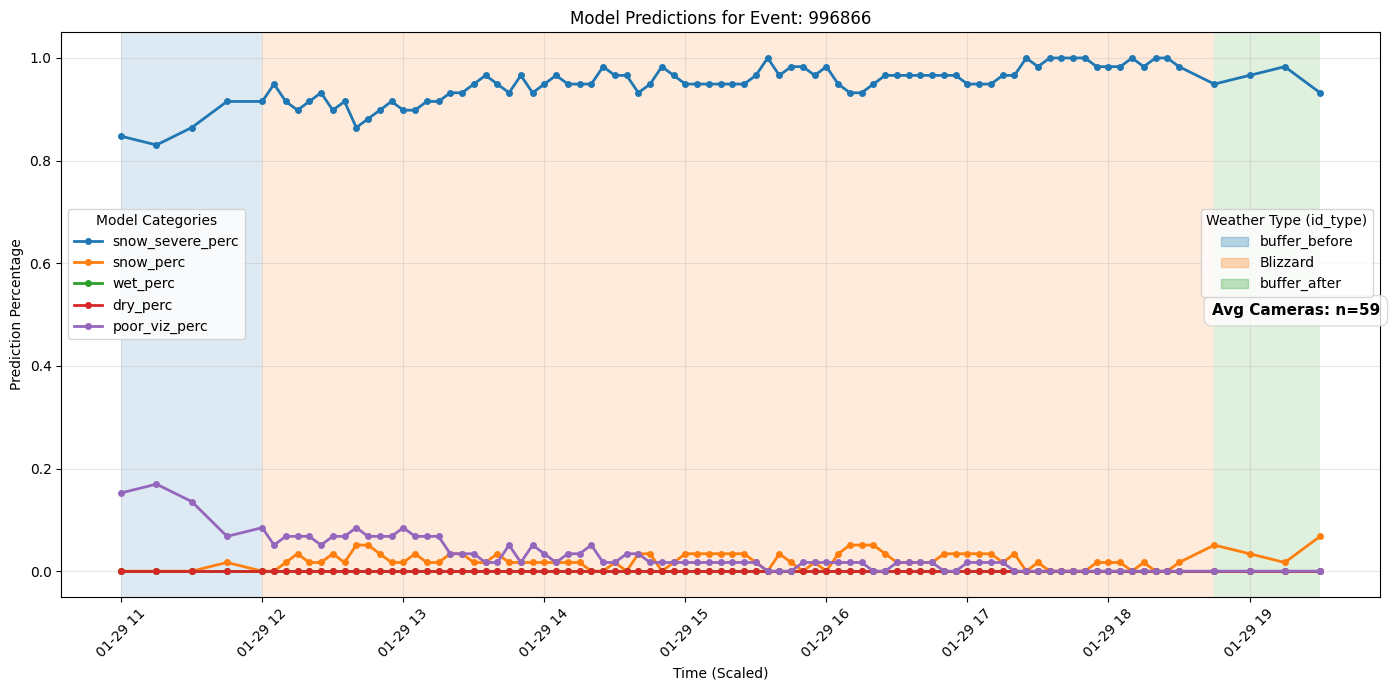

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


event_one_example = data[data["id_event"]==996866]

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Shading Colors
# Get unique event types from your data to ensure we have a color for everything
unique_types = event_one_example['id_type'].unique()
# Using a standard colormap (tab10) to assign colors automatically
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting
plt.figure(figsize=(14, 7))

# --- ADD SHADING FIRST (so it sits behind the lines) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    
    plt.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- PLOT YOUR 5 COLUMNS ---
columns_to_plot = catslist_perc
for col in columns_to_plot:
    plt.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
plt.title(f"Model Predictions for Event: {event_one_example['id_event'].iloc[0]}")
plt.xlabel("Time (Scaled)")
plt.ylabel("Prediction Percentage")

# Create a dual legend
# Legend 1: Your prediction lines
line_legend = plt.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
plt.gca().add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]

plt.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7),title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())

plt.gca().text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=plt.gca().transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

/tmp/tmp.bk8e7nH0kY/ipykernel_1800498/1566636222.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')


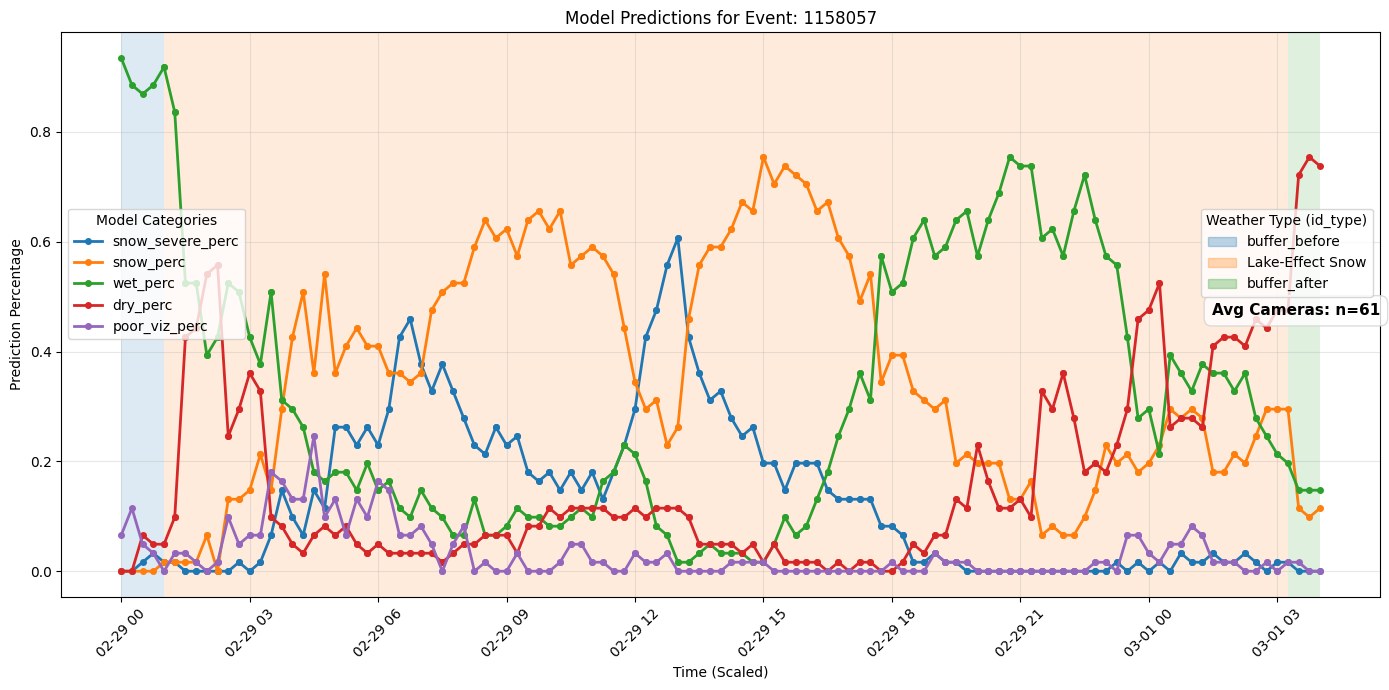

In [15]:


event_one_example = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"]==1158057]

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Convert and Sort
event_one_example['datetime_plot'] = pd.to_datetime(event_one_example['datetime'], format='%Y%m%d_%H%M')
event_one_example = event_one_example.sort_values('datetime_plot').reset_index(drop=True)

# 2. Setup Shading Colors
# Get unique event types from your data to ensure we have a color for everything
unique_types = event_one_example['id_type'].unique()
# Using a standard colormap (tab10) to assign colors automatically
cmap = plt.get_cmap('tab10')
state_colors = {etype: cmap(i) for i, etype in enumerate(unique_types)}

# 3. Plotting
plt.figure(figsize=(14, 7))

# --- ADD SHADING FIRST (so it sits behind the lines) ---
for i in range(len(event_one_example) - 1):
    start = event_one_example.loc[i, 'datetime_plot']
    end = event_one_example.loc[i+1, 'datetime_plot']
    etype = event_one_example.loc[i, 'id_type']
    
    plt.axvspan(start, end, color=state_colors[etype], alpha=0.15, lw=0)

# --- PLOT YOUR 5 COLUMNS ---
columns_to_plot = catslist_perc
for col in columns_to_plot:
    plt.plot(event_one_example['datetime_plot'], event_one_example[col], 
             label=col, marker='o', markersize=4, linewidth=2)

# 4. Formatting
plt.title(f"Model Predictions for Event: {event_one_example['id_event'].iloc[0]}")
plt.xlabel("Time (Scaled)")
plt.ylabel("Prediction Percentage")

# Create a dual legend
# Legend 1: Your prediction lines
line_legend = plt.legend(loc='upper left', title="Model Categories",  bbox_to_anchor=(0, 0.70))
plt.gca().add_artist(line_legend)

# Legend 2: The shading types (Custom Patches)
shading_patches = [mpatches.Patch(color=state_colors[etype], alpha=0.3, label=etype) for etype in unique_types]

plt.legend(handles=shading_patches, loc='upper right', bbox_to_anchor=(1, 0.7),title="Weather Type (id_type)")

# Add avg number of cams included in each time step
avg_n = int(event_one_example['totalcams'].mean())

plt.gca().text(
    1, 0.52, 
    f"Avg Cameras: n={avg_n}", 
    transform=plt.gca().transAxes, 
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='lightgray'),
    fontsize=11, 
    fontweight='bold'
)

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Aggregated by storm type

In [36]:
stats_2.head(2)

,id_event,id_ep,id_type,id_loc,id_wfo,datetime,modelfile,sites,prob_avg,qpe_avg,snow_severe,snow,wet,dry,poor_viz,totalcams,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,snow_severe_qpe,snow_qpe,wet_qpe,dry_qpe,poor_viz_qpe,snow_severe_prob,snow_prob,wet_prob,dry_prob,poor_viz_prob
0,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1200,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.866525,1.362712,54,0,0,0,5,59,0.9153,0.0,0.0,0.0,0.0847,1.354,0.0,0.0,0.0,1.46,0.894,0.0,0.0,0.0,0.573
1,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1205,/home/csutter/DRIVE-clean/operational_runs_QPE...,"['Skyline_1970', 'Skyline_1971', 'Skyline_1972...",0.850393,1.325424,56,0,0,0,3,59,0.9492,0.0,0.0,0.0,0.0508,1.321,0.0,0.0,0.0,1.40,0.864,0.0,0.0,0.0,0.590


In [53]:
stats_2.columns

Index(['id_event', 'id_ep', 'id_type', 'id_loc', 'id_wfo', 'datetime',
       'modelfile', 'sites', 'prob_avg', 'qpe_avg', 'snow_severe', 'snow',
       'wet', 'dry', 'poor_viz', 'totalcams', 'snow_severe_perc', 'snow_perc',
       'wet_perc', 'dry_perc', 'poor_viz_perc', 'snow_severe_qpe', 'snow_qpe',
       'wet_qpe', 'dry_qpe', 'poor_viz_qpe', 'qpe_product_snow_severe',
       'qpe_product_snow', 'qpe_product_wet', 'qpe_product_dry',
       'qpe_product_poor_viz', 'snow_severe_prob', 'snow_prob', 'wet_prob',
       'dry_prob', 'poor_viz_prob'],
      dtype='object')

In [48]:
print(np.unique(stats_2['id_type']))

['Blizzard' 'Heavy Rain' 'Heavy Snow' 'Lake-Effect Snow' 'Winter Storm'
 'Winter Weather' 'buffer_after' 'buffer_before']


,id_type,id_event
0,Blizzard,"[996866, 996866, 996866, 996866, 996866, 99686..."
1,Heavy Rain,"[1193087, 1193087, 1193087, 1193087, 1193087, ..."
2,Heavy Snow,"[1224211, 1224211, 1224211, 1224211, 1224211, ..."
3,Lake-Effect Snow,"[1158057, 1158057, 1158057, 1158057, 1158057, ..."
4,Winter Storm,"[1146894, 1146894, 1146894, 1146894, 1146894, ..."
5,Winter Weather,"[1148041, 1148041, 1148041, 1148041, 1148041, ..."


,id_type,snow_severe,snow,wet,dry,poor_viz,totalcams,qpe_product_snow_severe,qpe_product_snow,qpe_product_wet,qpe_product_dry,qpe_product_poor_viz
0,Lake-Effect Snow,33428,93508,52912,57155,5268,242271,27698.993,25005.096,6357.754,2219.636,3802.864
1,buffer_after,491,4565,1804,2780,144,9784,331.093,996.784,83.883,21.894,10.101
2,buffer_before,726,3755,2500,2692,143,9816,481.176,865.343,380.195,188.224,74.399


,id_type,snow_severe,snow,wet,dry,poor_viz,totalcams,qpe_product_snow_severe,qpe_product_snow,qpe_product_wet,qpe_product_dry,qpe_product_poor_viz,snow_severe_proportion,snow_severe_qpe_avg,snow_proportion,snow_qpe_avg,wet_proportion,wet_qpe_avg,dry_proportion,dry_qpe_avg,poor_viz_proportion,poor_viz_qpe_avg
0,Lake-Effect Snow,33428,93508,52912,57155,5268,242271,27698.993,25005.096,6357.754,2219.636,3802.864,0.137978,0.828617,0.385964,0.267411,0.218400,0.120157,0.235914,0.038835,0.021744,0.721880
1,buffer_after,491,4565,1804,2780,144,9784,331.093,996.784,83.883,21.894,10.101,0.050184,0.674324,0.466578,0.218354,0.184383,0.046498,0.284137,0.007876,0.014718,0.070146
2,buffer_before,726,3755,2500,2692,143,9816,481.176,865.343,380.195,188.224,74.399,0.073961,0.662777,0.382539,0.230451,0.254686,0.152078,0.274246,0.069920,0.014568,0.520273


In [ ]:
###### To see example how code works for data cutting (all of this is done in summ_byevent() function below this cell)
# OPTIONAL/ DEMONSTRATIVE CODE BELOW

# Grab list of event IDs ("id_event") for each weather pattern (e.g. Blizzard). Have to do it this way b/c of how we've tied in buffers as id_types, so we need to use id_event as the keys that connects 


weatherevents = stats_2[stats_2["id_type"].isin(['Blizzard', 'Heavy Rain' ,'Heavy Snow', 'Lake-Effect Snow', 'Winter Storm','Winter Weather'])]

weather_and_ids = weatherevents.groupby('id_type')['id_event'].agg(list).reset_index()
display(weather_and_ids)

# Get a subset the main df of just those rows that for that weather pattern (using the list of list made in step 1)

# for type in weather_and_ids["id_type"]:
type = "Lake-Effect Snow"
eventlist = weather_and_ids[weather_and_ids["id_type"]==type]["id_event"].item()
# grab those events from the main df
subsetevents = stats_2[stats_2["id_event"].isin(eventlist)].reset_index()

# Aggregate that subsetted df by cat (for bar plot) this is the x axis, and 1) sum the number of cam preds for each class (the x grouping), and 2) need to calculate the avg QPE for that class (the x grouping), which will take some calculation since we only have it averaged for each class by event (and w/ these plot we're aggregating one step up further across weather patterns. So will need to a) do sumproduct of (wet_qpe * wet for each event) / (sum of wet across weather pattern)

#  group by before buffer, during event, and after buffer
group_stormphase_sumcats = subsetevents[["id_type","snow_severe", "snow", "wet", "dry", "poor_viz","totalcams",'qpe_product_snow_severe',
       'qpe_product_snow', 'qpe_product_wet', 'qpe_product_dry',
       'qpe_product_poor_viz']].groupby(["id_type"]).sum().reset_index()

display(group_stormphase_sumcats.head(4))


# Add aggregated columns we need:

for cat in catslist:
    group_stormphase_sumcats[f"{cat}_proportion"] = group_stormphase_sumcats[cat]/group_stormphase_sumcats["totalcams"]
    group_stormphase_sumcats[f"{cat}_qpe_avg"] = group_stormphase_sumcats[f"qpe_product_{cat}"]/group_stormphase_sumcats[cat]
# cat_pred_proportions = []
# cat_qpe_avg = []
display(group_stormphase_sumcats.head(4))


In [99]:
def summ_byevent(type = "Lake-Effect Snow", maindf = stats_2):
    # Grab list of event IDs ("id_event") for each weather pattern (e.g. Blizzard). Have to do it this way b/c of how we've tied in buffers as id_types, so we need to use id_event as the keys that connects 

    weatherevents = maindf[maindf["id_type"].isin(['Blizzard', 'Heavy Rain' ,'Heavy Snow', 'Lake-Effect Snow', 'Winter Storm','Winter Weather'])]

    weather_and_ids = weatherevents.groupby('id_type')['id_event'].agg(list).reset_index()
    display(weather_and_ids)

    # Get a subset the main df of just those rows that for that weather pattern (using the list of list made in step 1)

    # for type in weather_and_ids["id_type"]:
    eventlist = weather_and_ids[weather_and_ids["id_type"]==type]["id_event"].item()
    # grab those events from the main df
    subsetevents = maindf[maindf["id_event"].isin(eventlist)].reset_index()

    # Aggregate that subsetted df by cat (for bar plot) this is the x axis, and 1) sum the number of cam preds for each class (the x grouping), and 2) need to calculate the avg QPE for that class (the x grouping), which will take some calculation since we only have it averaged for each class by event (and w/ these plot we're aggregating one step up further across weather patterns. So will need to a) do sumproduct of (wet_qpe * wet for each event) / (sum of wet across weather pattern)

    #  group by before buffer, during event, and after buffer
    group_stormphase_sumcats = subsetevents[["id_type","snow_severe", "snow", "wet", "dry", "poor_viz","totalcams",'qpe_product_snow_severe',
        'qpe_product_snow', 'qpe_product_wet', 'qpe_product_dry',
        'qpe_product_poor_viz']].groupby(["id_type"]).sum().reset_index()

    display(group_stormphase_sumcats.head(4))


    # Add aggregated columns we need:

    for cat in catslist:
        group_stormphase_sumcats[f"{cat}_proportion"] = group_stormphase_sumcats[cat]/group_stormphase_sumcats["totalcams"]
        group_stormphase_sumcats[f"{cat}_qpe_avg"] = group_stormphase_sumcats[f"qpe_product_{cat}"]/group_stormphase_sumcats[cat]
    # cat_pred_proportions = []
    # cat_qpe_avg = []
    display(group_stormphase_sumcats.head(4))

    return group_stormphase_sumcats

In [75]:
df = group_stormphase_sumcats

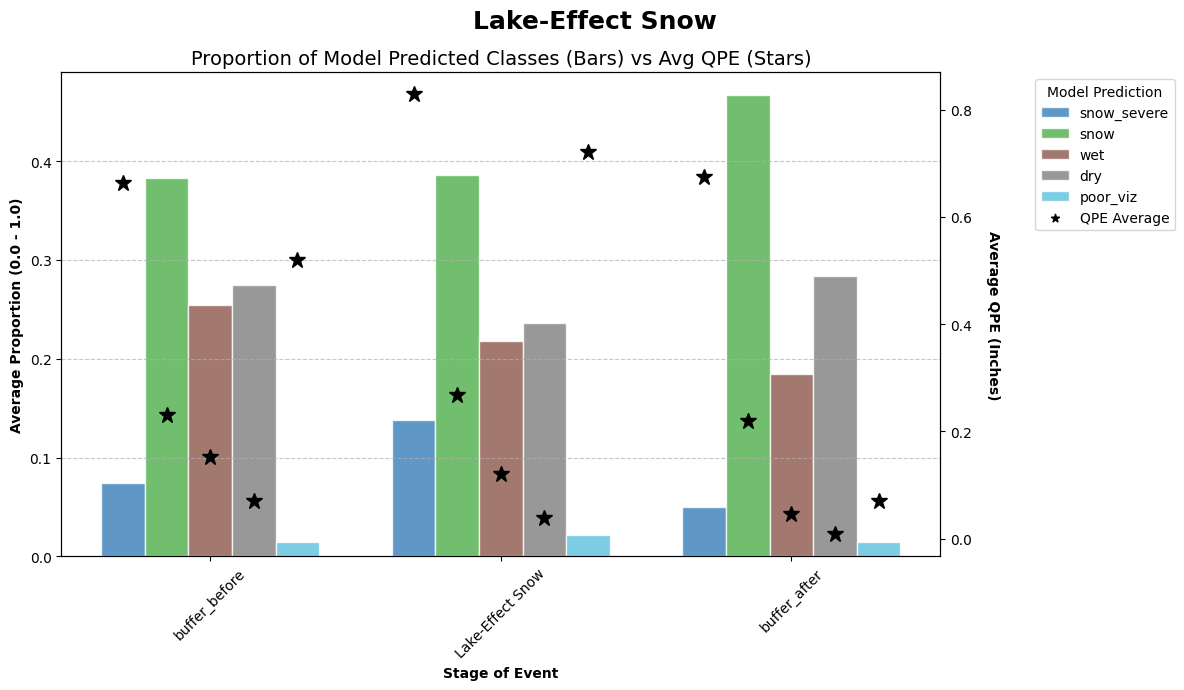

In [98]:
import matplotlib.pyplot as plt
import numpy as np

def make_plot(df, evtype):


    # 1. Setup Data and Categories
    categories = catslist

    # --- CHANGE 1: Define your specific order here ---
    event_types = ['buffer_before', evtype, 'buffer_after'] 

    # --- CHANGE 2: Define your specific color mapping here ---
    color_map = {
        'snow': '#4daf4a',        
        'snow_severe': '#377eb8', 
        'wet': '#8c564b',         
        'poor_viz': '#5bc0de',    
        'dry': '#7f7f7f'          
    }

    x = np.arange(len(event_types))
    width = 0.15 

    fig, ax1 = plt.subplots(figsize=(12, 7))
    ax2 = ax1.twinx()

    # 2. Iterate through each category to plot bars and stars
    for i, cat in enumerate(categories):
        offset = (i - len(categories)/2) * width + (width/2)
        
        prop_col = f"{cat}_proportion"
        qpe_col = f"{cat}_qpe_avg"
        
        # We use .loc[event_types] to force the specific order we defined above
        y_values = df.groupby('id_type')[prop_col].mean().loc[event_types]
        qpe_values = df.groupby('id_type')[qpe_col].mean().loc[event_types]
        
        # Plot Bars with specific colors from our map
        ax1.bar(x + offset, y_values, width, 
                label=cat, 
                color=color_map.get(cat, '#7f7f7f'), # Fallback to grey if cat not in dict
                edgecolor='white', 
                alpha=0.8)
        
        # Plot Stars
        ax2.plot(x + offset, qpe_values, 
                marker='*', color='black', linestyle='None', markersize=12)

    # 3. Formatting (Matching your preferred style)
    plt.suptitle(f"{evtype}", fontsize=18, fontweight='bold')
    ax1.set_title("Proportion of Model Predicted Classes (Bars) vs Avg QPE (Stars)", fontsize=14)

    ax1.set_ylabel("Average Proportion (0.0 - 1.0)", fontweight='bold')
    ax2.set_ylabel("Average QPE (Inches)", fontweight='bold', rotation=270, labelpad=20)
    ax1.set_xlabel("Stage of Event", fontweight='bold')

    ax1.set_xticks(x)
    ax1.set_xticklabels(event_types, rotation=45)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Legend
    ax2.scatter([], [], marker='*', color='black', label='QPE Average')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, title="Model Prediction", 
            bbox_to_anchor=(1.1, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

,id_type,id_event
0,Blizzard,"[996866, 996866, 996866, 996866, 996866, 99686..."
1,Heavy Rain,"[1193087, 1193087, 1193087, 1193087, 1193087, ..."
2,Heavy Snow,"[1224211, 1224211, 1224211, 1224211, 1224211, ..."
3,Lake-Effect Snow,"[1158057, 1158057, 1158057, 1158057, 1158057, ..."
4,Winter Storm,"[1146894, 1146894, 1146894, 1146894, 1146894, ..."
5,Winter Weather,"[1148041, 1148041, 1148041, 1148041, 1148041, ..."


,id_type,snow_severe,snow,wet,dry,poor_viz,totalcams,qpe_product_snow_severe,qpe_product_snow,qpe_product_wet,qpe_product_dry,qpe_product_poor_viz
0,Blizzard,57358,7223,1109,438,2929,69057,70594.093,4387.615,1387.802,16.81,4292.694
1,buffer_after,734,266,21,64,29,1114,777.059,38.601,0.400,0.00,14.498
2,buffer_before,469,171,381,2,98,1121,796.492,232.723,691.433,0.00,190.900


,id_type,snow_severe,snow,wet,dry,poor_viz,totalcams,qpe_product_snow_severe,qpe_product_snow,qpe_product_wet,qpe_product_dry,qpe_product_poor_viz,snow_severe_proportion,snow_severe_qpe_avg,snow_proportion,snow_qpe_avg,wet_proportion,wet_qpe_avg,dry_proportion,dry_qpe_avg,poor_viz_proportion,poor_viz_qpe_avg
0,Blizzard,57358,7223,1109,438,2929,69057,70594.093,4387.615,1387.802,16.81,4292.694,0.830589,1.230763,0.104595,0.607451,0.016059,1.251399,0.006343,0.038379,0.042414,1.465583
1,buffer_after,734,266,21,64,29,1114,777.059,38.601,0.400,0.00,14.498,0.658887,1.058663,0.238779,0.145117,0.018851,0.019048,0.057451,0.000000,0.026032,0.499931
2,buffer_before,469,171,381,2,98,1121,796.492,232.723,691.433,0.00,190.900,0.418376,1.698277,0.152542,1.360953,0.339875,1.814785,0.001784,0.000000,0.087422,1.947959


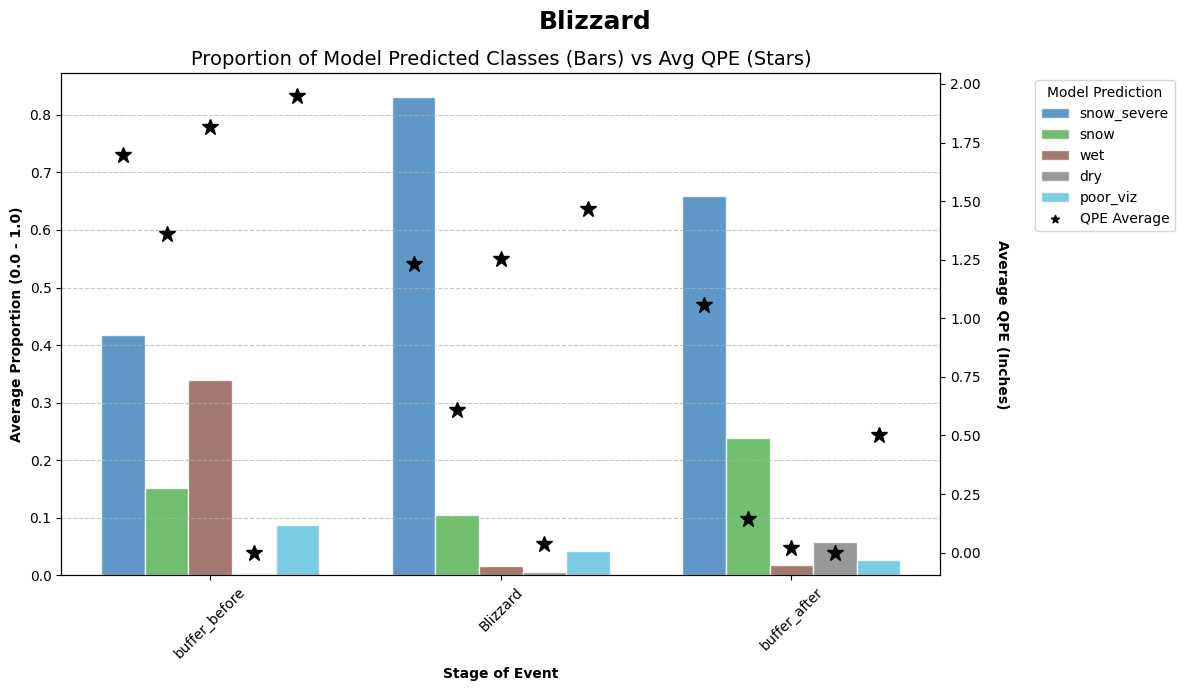

In [103]:
# CALL ON FUNCTIONS

weathertype = 'Blizzard'

output_event_summ = summ_byevent(type = weathertype, maindf = stats_2)
df = make_plot(output_event_summ, evtype = weathertype)

### Old grouped histogram plots without QPE

In [18]:
# DEFINE PLOT FUNCTION
# import matplotlib.pyplot as plt

# 1. Calculate the proportions for each row

def makeplot(df,evtype):

    # df = group_stormphase_sumcats

    prop_cols = []

    for col in catslist:
        prop_name = col + '_prop'
        df[prop_name] = df[col] / df['totalcams']
        prop_cols.append(prop_name)

    # 2. Group by id_type and get the average proportions
    # This creates a table where rows = id_type and columns = average cat proportions
    summary_df = df.groupby('id_type', sort=False)[prop_cols].mean()

    # Rename columns back to original names for a cleaner legend
    summary_df.columns = catslist


    # 3. Plotting
    ax = summary_df.plot(kind='bar', 
                        stacked=False, 
                        figsize=(12, 7), 
                        colormap='tab10', 
                        edgecolor='white')

    # 4. Formatting
    # The main centered "Super" title
    plt.suptitle(f"{evtype}", fontsize=18, fontweight='bold')

    # The secondary subtitle (your original title)
    plt.title(f"Proportion of Model Predicted Classes - Before, During, and After", fontsize=14)
    
    plt.ylabel("Average Proportion (0.0 - 1.0)")
    plt.xlabel("Stage of Event")
    plt.legend(title="Model Prediction", bbox_to_anchor=(.88, 1), loc='upper left')
    plt.xticks(rotation=45)

    # Optional: Add a grid for the y-axis to help read proportions
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [44]:
print(np.unique(stats_2["id_type"]))

['Blizzard' 'Heavy Rain' 'Heavy Snow' 'Lake-Effect Snow' 'Winter Storm'
 'Winter Weather' 'buffer_after' 'buffer_before']


,id_type,id_event
0,Blizzard,"[996866, 996866, 996866, 996866, 996866, 99686..."
1,Heavy Rain,"[1193087, 1193087, 1193087, 1193087, 1193087, ..."
2,Heavy Snow,"[1224211, 1224211, 1224211, 1224211, 1224211, ..."
3,Lake-Effect Snow,"[1158057, 1158057, 1158057, 1158057, 1158057, ..."
4,Winter Storm,"[1146894, 1146894, 1146894, 1146894, 1146894, ..."
5,Winter Weather,"[1148041, 1148041, 1148041, 1148041, 1148041, ..."


,id_type,snow_severe,snow,wet,dry,poor_viz,totalcams
0,buffer_before,469,171,381,2,98,1121
1,Blizzard,57358,7223,1109,438,2929,69057
2,buffer_after,734,266,21,64,29,1114


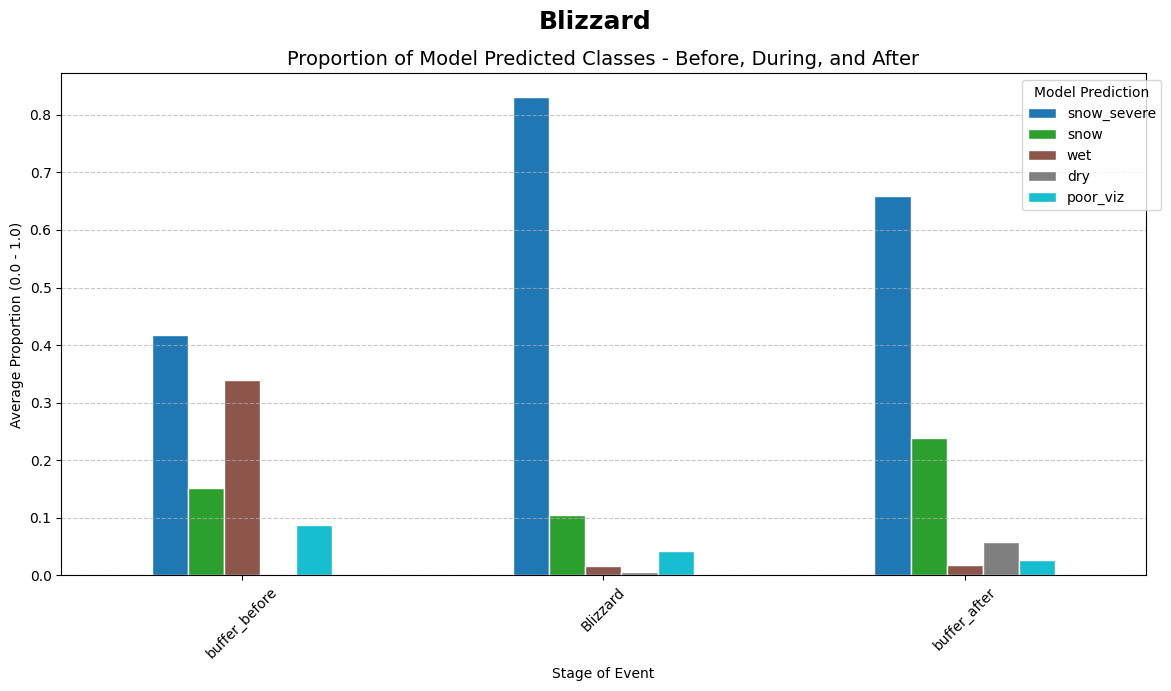

,id_type,snow_severe,snow,wet,dry,poor_viz,totalcams
0,buffer_before,0,0,3027,3108,11,6146
1,Heavy Rain,0,0,991,519,37,1547
2,buffer_after,0,0,5887,170,43,6100


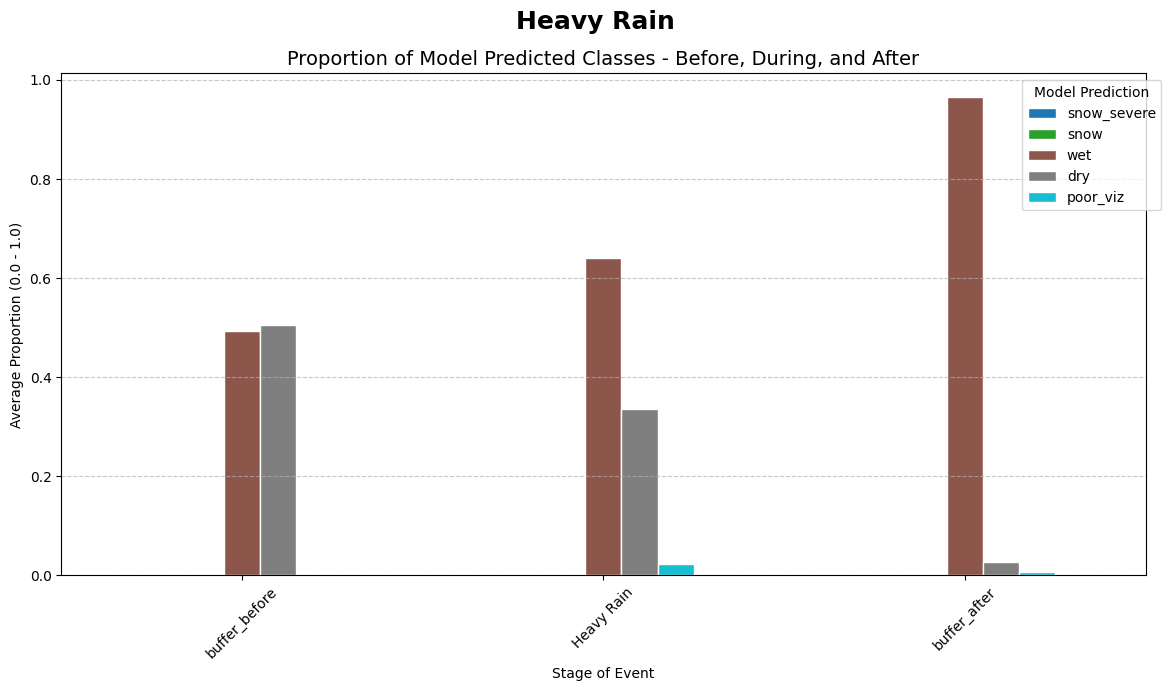

,id_type,snow_severe,snow,wet,dry,poor_viz,totalcams
0,buffer_before,10,148,945,2026,79,3208
1,Heavy Snow,9788,23137,15012,4016,2657,54610
2,buffer_after,225,719,2025,174,65,3208


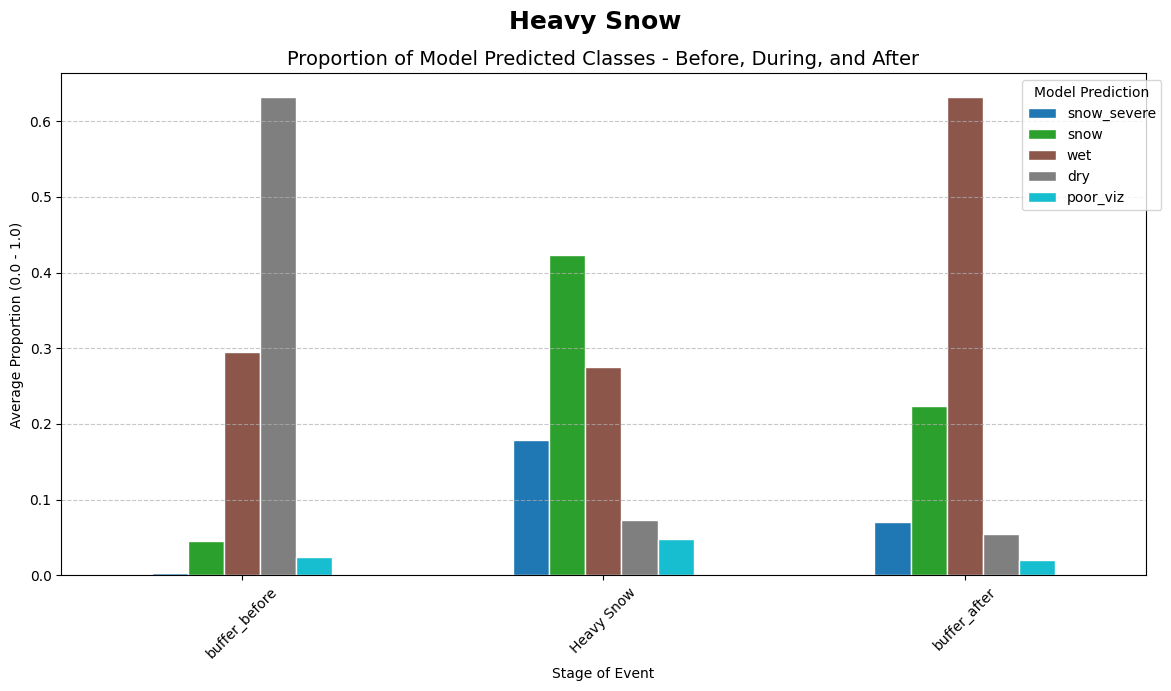

,id_type,snow_severe,snow,wet,dry,poor_viz,totalcams
0,buffer_before,726,3755,2500,2692,143,9816
1,Lake-Effect Snow,33428,93508,52912,57155,5268,242271
2,buffer_after,491,4565,1804,2780,144,9784


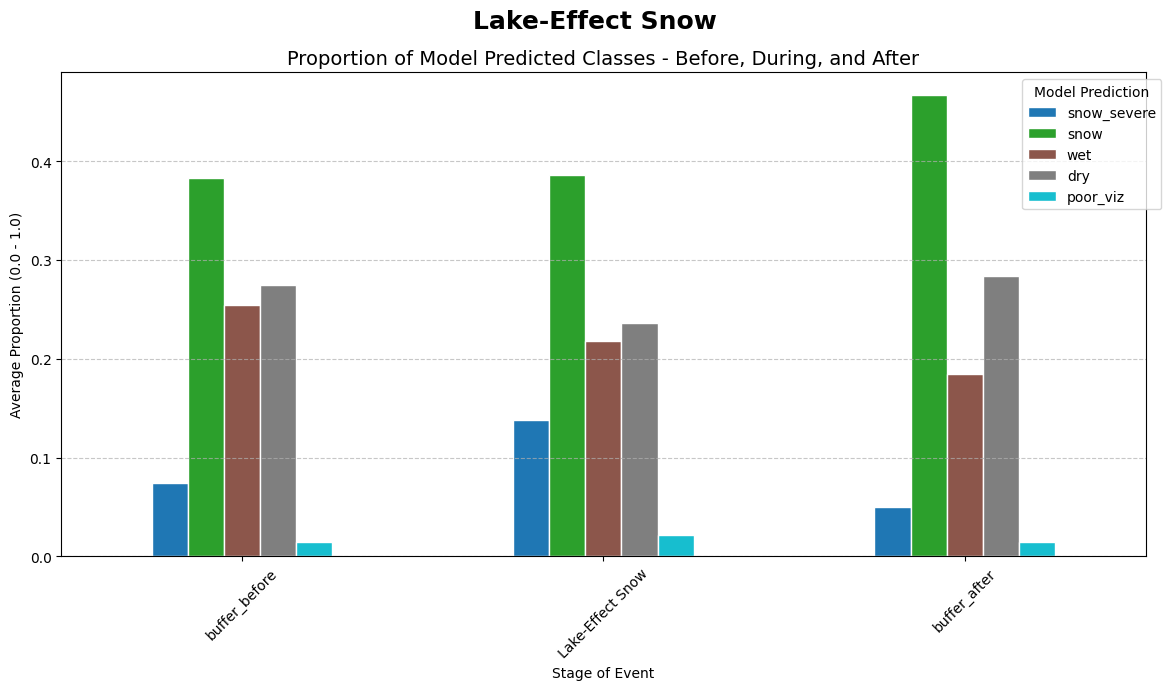

,id_type,snow_severe,snow,wet,dry,poor_viz,totalcams
0,buffer_before,36,373,480,1002,37,1928
1,Winter Storm,11620,21527,11698,7063,2197,54105
2,buffer_after,189,721,521,579,34,2044


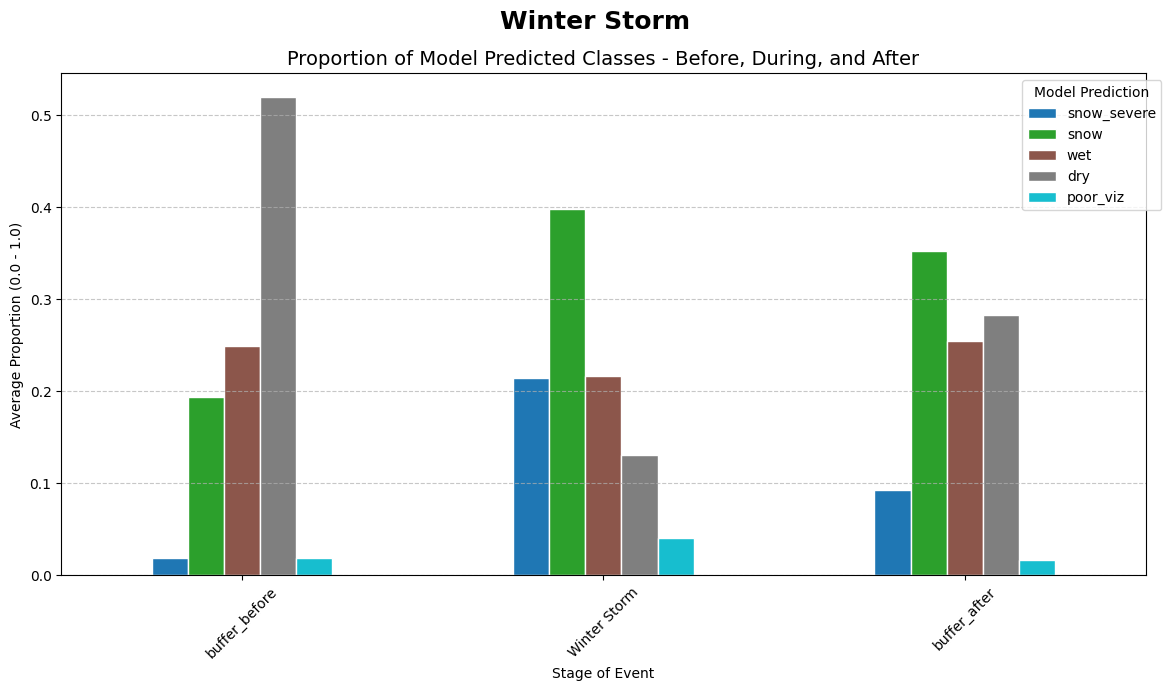

,id_type,snow_severe,snow,wet,dry,poor_viz,totalcams
0,buffer_before,152,458,6112,13363,488,20573
1,Winter Weather,20473,69006,114059,22983,10329,236850
2,buffer_after,963,4062,13629,1361,555,20570


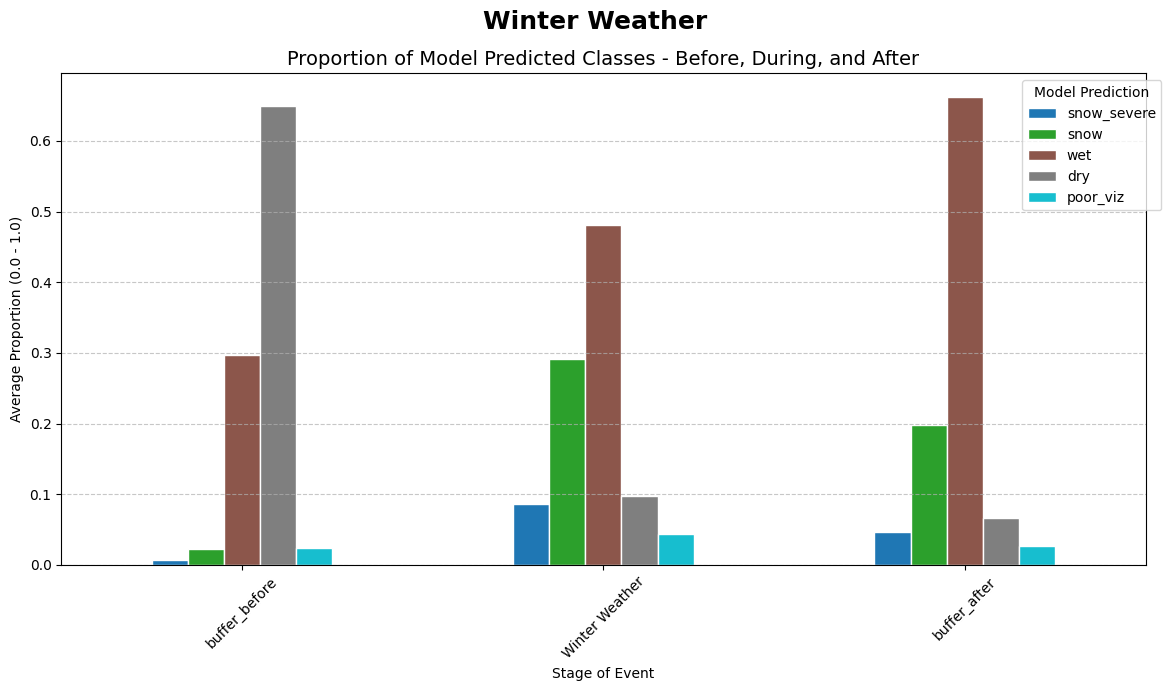

In [19]:
stats_2

# grab event ids associated with each main weather type. Ignore buffer_before and buffer_after
weatherevents = stats_2[((stats_2["id_type"]!="buffer_before")&(stats_2["id_type"]!="buffer_after"))]

g1 = weatherevents.groupby('id_type')['id_event'].agg(list).reset_index()
display(g1)


# for each even type (blizzard), subset main df to just those id_event (which will also tie in buffer_before and buffer_after),  and then aggregate stats for them

for type in g1["id_type"]:
    eventlist = g1[g1["id_type"]==type]["id_event"].item()
    # grab those events from the main df
    subsetevents = stats_2[stats_2["id_event"].isin(eventlist)].reset_index()
    #  group by before buffer, during event, and after buffer
    group_stormphase_sumcats = subsetevents[["id_type","snow_severe", "snow", "wet", "dry", "poor_viz","totalcams"]].groupby(["id_type"]).sum().reset_index()

    order_df = ["buffer_before",type, "buffer_after"]
    
    group_stormphase_sumcats = group_stormphase_sumcats.set_index("id_type").loc[order_df].reset_index()

    display(group_stormphase_sumcats)

    makeplot(df = group_stormphase_sumcats,evtype = type)

    # Could run longer buffer (before/after) to get a better picture / more data there (e.g. many events themselves run a day or more, but for buffer I only pulled the 60 min before / after. Could also cosnider running the frequency that I ran the cases at (e.g. if 5 min rather thand 15)

